# Windowing, chronological splits and leakage

**Learning objective:** Convert one long time series into supervised examples and understand why time-series splits must preserve temporal order.

This notebook is part of the TensorFlow/Keras learning track. It is designed to be read top-to-bottom: intuition → shapes → mathematics → TensorFlow implementation → observed result → interpretation.

> GitHub renders the committed executed output as a static learning artifact. Clone the repository and rerun it in Jupyter/VS Code for live experimentation.


In [1]:
import os, warnings, random
from pathlib import Path
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

print("TensorFlow:", tf.__version__)
print("Keras:", tf.keras.__version__ if hasattr(tf.keras, "__version__") else "bundled with TensorFlow")
print("Execution device(s):", [d.device_type for d in tf.config.list_logical_devices()])


2026-09-21 07:13:11.634990: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1789974791.650234    2767 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1789974791.654604    2767 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


TensorFlow: 2.18.1
Keras: 3.15.1
Execution device(s): ['CPU']


2026-09-21 07:13:13.354289: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [2]:
n = 120
t = np.arange(n)
series = np.sin(t/8) + 0.005*t
lookback = 12
X, y = [], []
for i in range(len(series)-lookback):
    X.append(series[i:i+lookback]); y.append(series[i+lookback])
X = np.asarray(X)[...,None]; y = np.asarray(y)
print("X:", X.shape, "y:", y.shape)
print("first window:", np.round(X[0,:,0],3)); print("first target:", round(float(y[0]),3))


X: (108, 12, 1) y: (108,)
first window: [0.    0.13  0.257 0.381 0.499 0.61  0.712 0.803 0.881 0.947 0.999 1.036]
first target: 1.057


,split,start,end
0,train,0,75
1,validation,75,91
2,test,91,108


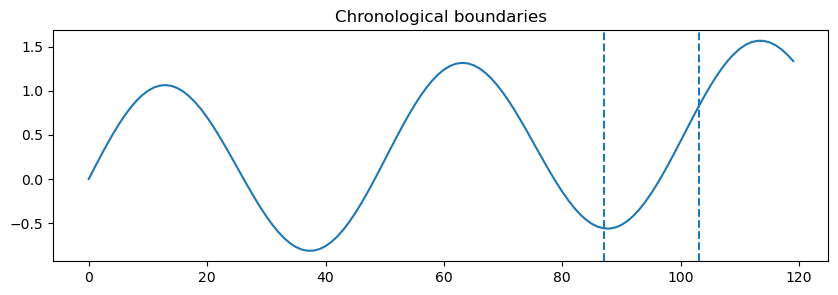

In [3]:
train_end = int(len(X)*0.7); val_end = int(len(X)*0.85)
splits = pd.DataFrame({"split":["train","validation","test"], "start":[0,train_end,val_end], "end":[train_end,val_end,len(X)]})
display(splits)
plt.figure(figsize=(10,3)); plt.plot(series); plt.axvline(train_end+lookback, ls="--"); plt.axvline(val_end+lookback, ls="--"); plt.title("Chronological boundaries"); plt.show()


Random shuffling before splitting can leak future regimes into training. We may shuffle **training windows during optimization**, but the dataset partitions themselves remain chronological.
